# **LINEAR REGRESSION**

## ***Overview***



# **1. Setup & Dependencies**

This section outlines the initial setup required for the notebook, including the installation of necessary libraries for data processing and model training.

In [1]:
import pandas as pd
import numpy as np
import sklearn.linear_model as lm 
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import curve_fit


# **2. Data Acquisition**

This section covers data loading and provides an overview of the dataset.

## ***2.1. Load Train, Validation and Test Sets***

This section is responsible for loading the prepared datasets used for model training and evaluation. The data has been preprocessed and split into three subsets:

- **Training set**: used to fit the model  
- **Validation set**: used for hyperparameter tuning (GridSearchCV)  
- **Test set**: used for final evaluation  


In [2]:
traindf = pd.read_csv("../data/processed/train.csv")
valdf = pd.read_csv("../data/processed/val.csv")
testdf = pd.read_csv("../data/processed/test.csv")

## ***2.2. Dataset Overview***

This step verifies the size and structure of each dataset split to ensure correctness after preprocessing and data splitting.

In [3]:
def summarize_dataset(name, df, total):
    print(f"{name} set:")
    print(f"  Samples : {df.shape[0]:,}")
    print(f"  Features: {df.shape[1]}")
    print(f"  Ratio   : {df.shape[0] / total:.2%}\n")

total_samples = len(traindf) + len(valdf) + len(testdf)

summarize_dataset("Train", traindf, total_samples)
summarize_dataset("Validation", valdf, total_samples)
summarize_dataset("Test", testdf, total_samples)

Train set:
  Samples : 172,064
  Features: 65
  Ratio   : 64.00%

Validation set:
  Samples : 43,016
  Features: 65
  Ratio   : 16.00%

Test set:
  Samples : 53,770
  Features: 65
  Ratio   : 20.00%



## ***2.3. Feature Overview***

This step provides an overview of the numerical feature distributions, including count, mean, standard deviation, minimum, quartiles, and maximum values. All listed features have 172,064 valid observations, showing that these columns are complete with no missing data.

In [4]:
traindf.describe()

,serviceCharge,picturecount,pricetrend,yearConstructed,baseRent,livingSpace,noRooms,floor,numberOfFloors,newlyConst,balcony,hasKitchen,cellar,lift,garden,regio2_freq,totalRent
count,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000,172064.000000
mean,139.793800,9.062767,3.296829,1969.945741,558.067104,69.095569,2.553384,1.989545,3.204569,0.078203,0.616579,0.344494,0.639960,0.236395,0.196392,0.011897,701.701676
std,63.154279,4.932243,1.773138,32.748675,295.504944,23.591265,0.844273,1.208368,1.017033,0.268492,0.486221,0.475204,0.480013,0.424868,0.397270,0.014946,310.890174
min,0.000000,0.000000,-1.850000,1881.000000,0.000000,5.000000,1.000000,-1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000045,0.000000
25%,96.000000,6.000000,2.000000,1959.000000,338.000000,54.000000,2.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002031,495.000000
50%,130.000000,9.000000,3.340000,1973.000000,469.450000,66.000000,3.000000,2.000000,3.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.005200,622.000000
75%,179.000000,12.000000,4.480000,1992.000000,710.000000,82.160000,3.000000,3.000000,4.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.013982,825.000000
max,332.280000,23.000000,8.420000,2022.000000,1490.500000,136.500000,4.500000,6.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.051043,1757.530000


# **3. Regression Model Categories**

In this step, the regression models are divided into two main groups based on the relationship they capture between the input features and the target variable:

- **Linear Regression**
- **Non-linear Regression**

## ***3.1. Linear Regression***

For **Linear Regression**, the models are further classified into:

- **Single variable (Univariate) Linear Regression**: a model built using only one predictor variable
- **Multiple variables (Multivariate) Linear Regression**: a model built using two or more predictor variables

## ***3.1.1. Univariate Linear Regression***

In this step, the training dataset is separated into the target variable (**Y**) and individual input features (**X1** to **X16**) for univariate linear regression analysis.

- **Target variable (Y)**: `totalRent`
- **Input features**:
  - **X1**: `serviceCharge`
  - **X2**: `picturecount`
  - **X3**: `pricetrend`
  - **X4**: `yearConstructed`
  - **X5**: `baseRent`
  - **X6**: `livingSpace`
  - **X7**: `noRooms`
  - **X8**: `floor`
  - **X9**: `numberOfFloors`
  - **X10**: `newlyConst`
  - **X11**: `balcony`
  - **X12**: `hasKitchen`
  - **X13**: `cellar`
  - **X14**: `lift`
  - **X15**: `garden`
  - **X16**: `regio2_freq`

Each feature is stored separately as a DataFrame so that it can be used independently to train and evaluate a single-variable regression model.

In [5]:
feature_cols = [
    "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
    "baseRent", "livingSpace", "noRooms", "floor", "numberOfFloors",
    "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
    "garden", "regio2_freq"
 ]

target_col = "totalRent"

split_dfs = {
    "train": traindf,
    "validation": valdf,
    "test": testdf
}

# Keep each split separate to avoid overwriting Y/X variables.
split_targets = {}
split_features = {}

for split_name, df in split_dfs.items():
    split_targets[split_name] = pd.DataFrame(df[target_col])
    split_features[split_name] = {
        f"X{i}": pd.DataFrame(df[col])
        for i, col in enumerate(feature_cols, start=1)
    }

# Optional aliases for readability in later cells.
Y_train = split_targets["train"]
Y_val = split_targets["validation"]
Y_test = split_targets["test"]

X_train = split_features["train"]
X_val = split_features["validation"]
X_test = split_features["test"]

# Example access: X_train["X1"], X_val["X5"], X_test["X16"]

## ***3.1.2. Multivariate Linear Regression***

In this step, the multivariate linear regression analysis is divided into two separate configurations based on the inclusion of the `baseRent` feature:

- **Multivariate Linear Regression with `baseRent`**
- **Multivariate Linear Regression without `baseRent`**

This separation is useful for examining how much predictive power `baseRent` contributes to the model, and whether the remaining features can still explain the target variable effectively without it.

## **3.1.2.1 Multivariate Linear Regression with `baseRent`**
In this step, the dataset is separated into:
- the target variable (**y**): `totalRent`
- the input feature matrix (**X**) containing multiple predictors, including `baseRent`

In [6]:
X_with_baserent_train = traindf[
    [
        "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
        "baseRent", "livingSpace", "noRooms", "floor", "numberOfFloors",
        "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
        "garden", "regio2_freq"
    ]
]

X_with_baserent_val = valdf[
    [
        "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
        "baseRent", "livingSpace", "noRooms", "floor", "numberOfFloors",
        "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
        "garden", "regio2_freq"
    ]
]

X_with_baserent_test = testdf[
    [
        "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
        "baseRent", "livingSpace", "noRooms", "floor", "numberOfFloors",
        "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
        "garden", "regio2_freq"
    ]
]

## **3.1.2.2. Multivariate Linear Regression without `baseRent`**

This model uses multiple input features, excluding `baseRent`, to predict the target variable `totalRent`.

In this step, the dataset is separated into:
- the target variable (**y**): `totalRent`
- the input feature matrix (**X**) containing multiple predictors, without `baseRent`

In [7]:
X_without_baserent = traindf[
    [
        "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
        "livingSpace", "noRooms", "floor", "numberOfFloors",
        "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
        "garden", "regio2_freq"
    ]
]

X_without_baserent_val = valdf[
    [
        "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
        "livingSpace", "noRooms", "floor", "numberOfFloors",
        "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
        "garden", "regio2_freq"
    ]
]

X_without_baserent_test = testdf[
    [
        "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
        "livingSpace", "noRooms", "floor", "numberOfFloors",
        "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
        "garden", "regio2_freq"
    ]
]

## ***3.2. Non-linear Regression***

For **Non-linear Regression**, the models are designed to learn more complex, non-linear relationships between the features and the target.

In [8]:
x_col = "baseRent"   # đổi thành feature bạn muốn thử

X_nlr_train = traindf[x_col].values
X_nlr_vali= valdf[x_col].values
X_nlr_test= testdf[x_col].values

# **4. Univariate Linear Regression**

In this section, a separate linear regression model is trained for each individual feature.

Each model uses:
- **one input feature only**
- **the same target variable**: `totalRent`

The objective is to determine which single feature performs best in predicting the target variable.

For each univariate linear regression model, the following metrics are computed on both the training set and the test set:
- **MAE**
- **MSE**
- **RMSE**
- **R²**

The best-performing feature is then identified according to each metric separately, and an overall ranking is also produced for model selection.

In [9]:
feature_cols = [
    "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
    "baseRent", "livingSpace", "noRooms", "floor", "numberOfFloors",
    "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
    "garden", "regio2_freq"
]

target_col = "totalRent"

y_train = traindf[target_col].copy()
y_test = testdf[target_col].copy()


def build_metric_row(model_name, family, feature, split_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "family": family,
        "feature": feature,
        "split": split_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }


def rank_models(df):
    ranked = df.copy()
    ranked["rank_MAE"] = ranked["MAE"].rank(method="min", ascending=True)
    ranked["rank_MSE"] = ranked["MSE"].rank(method="min", ascending=True)
    ranked["rank_RMSE"] = ranked["RMSE"].rank(method="min", ascending=True)
    ranked["rank_R2"] = ranked["R2"].rank(method="min", ascending=False)
    ranked["overall_rank"] = (
        ranked["rank_MAE"]
        + ranked["rank_MSE"]
        + ranked["rank_RMSE"]
        + ranked["rank_R2"]
    )
    return ranked.sort_values(
        by=["overall_rank", "RMSE", "MAE", "MSE", "R2"],
        ascending=[True, True, True, True, False]
    ).reset_index(drop=True)


def best_by_metric(df):
    results = []
    metric_rules = {
        "MAE": True,
        "MSE": True,
        "RMSE": True,
        "R2": False
    }

    for metric, ascending in metric_rules.items():
        best_row = df.sort_values(by=metric, ascending=ascending).iloc[0]
        results.append({
            "metric": metric,
            "best_model": best_row["model"],
            "family": best_row["family"],
            "feature": best_row["feature"],
            "value": best_row[metric]
        })

    return pd.DataFrame(results)


def nonlinear_model(x, theta1, theta2):
    x = np.asarray(x, dtype=float)
    denom = theta2 + x
    denom = np.where(np.abs(denom) < 1e-8, 1e-8, denom)
    return (theta1 * x) / denom

ulr_rows = []
ulr_models = {}
ulr_predictions = {}

for col in feature_cols:
    X_train_one = traindf[[col]]
    X_test_one = testdf[[col]]

    model = LinearRegression()
    model.fit(X_train_one, y_train)

    y_train_pred = model.predict(X_train_one)
    y_test_pred = model.predict(X_test_one)

    ulr_models[col] = model
    ulr_predictions[col] = {
        "train_true": y_train.values,
        "train_pred": y_train_pred,
        "test_true": y_test.values,
        "test_pred": y_test_pred
    }

    ulr_rows.append(
        build_metric_row(
            model_name=f"ULR_{col}",
            family="Univariate Linear Regression",
            feature=col,
            split_name="train",
            y_true=y_train,
            y_pred=y_train_pred
        )
    )

    ulr_rows.append(
        build_metric_row(
            model_name=f"ULR_{col}",
            family="Univariate Linear Regression",
            feature=col,
            split_name="test",
            y_true=y_test,
            y_pred=y_test_pred
        )
    )

ulr_results = pd.DataFrame(ulr_rows)
ulr_results

,model,family,feature,split,MAE,MSE,RMSE,R2
0,ULR_serviceCharge,Univariate Linear Regression,serviceCharge,train,201.151527,72789.095695,269.794543,0.246896
1,ULR_serviceCharge,Univariate Linear Regression,serviceCharge,test,202.114387,73840.939411,271.736894,0.249009
2,ULR_picturecount,Univariate Linear Regression,picturecount,train,229.696893,92700.256004,304.467167,0.040888
3,ULR_picturecount,Univariate Linear Regression,picturecount,test,231.652960,94289.030366,307.065189,0.041044
4,ULR_pricetrend,Univariate Linear Regression,pricetrend,train,217.454555,83307.880958,288.631046,0.138065
5,ULR_pricetrend,Univariate Linear Regression,pricetrend,test,218.524325,84346.155167,290.424095,0.142167
6,ULR_yearConstructed,Univariate Linear Regression,yearConstructed,train,230.391376,92086.993949,303.458389,0.047233
7,ULR_yearConstructed,Univariate Linear Regression,yearConstructed,test,232.134737,93390.713407,305.598942,0.050180
8,ULR_baseRent,Univariate Linear Regression,baseRent,train,92.976931,26274.243902,162.093318,0.728157
9,ULR_baseRent,Univariate Linear Regression,baseRent,test,93.344566,26326.227965,162.253592,0.732252


## 4.1. Test-set Ranking for Univariate Linear Regression

This step ranks the univariate linear regression models using the test-set results.

Two views are provided:
- the **best model for each individual metric**
- the **overall ranking**, obtained by combining the ranking positions across MAE, MSE, RMSE, and R²

In [10]:
ulr_test_results = ulr_results[ulr_results["split"] == "test"].copy()
ulr_best_each_metric = best_by_metric(ulr_test_results)
ulr_test_ranked = rank_models(ulr_test_results)

print("Best univariate linear model for each metric:")
display(ulr_best_each_metric)

print("Overall ranking of univariate linear regression models:")
display(ulr_test_ranked)

best_ulr_feature = ulr_test_ranked.iloc[0]["feature"]
best_ulr_model_name = ulr_test_ranked.iloc[0]["model"]

print("Selected best Univariate Linear Regression model:", best_ulr_model_name)

Best univariate linear model for each metric:


,metric,best_model,family,feature,value
0,MAE,ULR_baseRent,Univariate Linear Regression,baseRent,93.344566
1,MSE,ULR_baseRent,Univariate Linear Regression,baseRent,26326.227965
2,RMSE,ULR_baseRent,Univariate Linear Regression,baseRent,162.253592
3,R2,ULR_baseRent,Univariate Linear Regression,baseRent,0.732252


Overall ranking of univariate linear regression models:


,model,family,feature,split,MAE,MSE,RMSE,R2,rank_MAE,rank_MSE,rank_RMSE,rank_R2,overall_rank
0,ULR_baseRent,Univariate Linear Regression,baseRent,test,93.344566,26326.227965,162.253592,0.732252,1.0,1.0,1.0,1.0,4.0
1,ULR_livingSpace,Univariate Linear Regression,livingSpace,test,197.023459,69345.837502,263.335978,0.294726,2.0,2.0,2.0,2.0,8.0
2,ULR_serviceCharge,Univariate Linear Regression,serviceCharge,test,202.114387,73840.939411,271.736894,0.249009,3.0,3.0,3.0,3.0,12.0
3,ULR_pricetrend,Univariate Linear Regression,pricetrend,test,218.524325,84346.155167,290.424095,0.142167,4.0,4.0,4.0,4.0,16.0
4,ULR_noRooms,Univariate Linear Regression,noRooms,test,223.867775,85027.042826,291.593969,0.135242,5.0,5.0,5.0,5.0,20.0
5,ULR_balcony,Univariate Linear Regression,balcony,test,230.062596,91956.930295,303.244011,0.064762,9.0,6.0,6.0,6.0,27.0
6,ULR_newlyConst,Univariate Linear Regression,newlyConst,test,227.501676,92132.307692,303.533042,0.062979,6.0,7.0,7.0,7.0,27.0
7,ULR_lift,Univariate Linear Regression,lift,test,229.468785,92995.420299,304.951505,0.054200,7.0,8.0,8.0,8.0,31.0
8,ULR_yearConstructed,Univariate Linear Regression,yearConstructed,test,232.134737,93390.713407,305.598942,0.050180,11.0,9.0,9.0,9.0,38.0
9,ULR_hasKitchen,Univariate Linear Regression,hasKitchen,test,229.527860,94148.208383,306.835800,0.042476,8.0,10.0,10.0,10.0,38.0


Selected best Univariate Linear Regression model: ULR_baseRent


# **5. Multivariate Linear Regression with `baseRent`**

In this section, a multivariate linear regression model is built using multiple input features, including `baseRent`.

The purpose of this model is to evaluate how well the target variable `totalRent` can be predicted when all selected explanatory variables are used together and `baseRent` is retained as a predictor.

The model is evaluated on both the training set and the test set using:
- **MAE**
- **MSE**
- **RMSE**
- **R²**

In [11]:
feature_cols_with_baserent = [
    "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
    "baseRent", "livingSpace", "noRooms", "floor", "numberOfFloors",
    "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
    "garden", "regio2_freq"
]

X_train_with_baserent = traindf[feature_cols_with_baserent]
X_test_with_baserent = testdf[feature_cols_with_baserent]

mlr_with_baserent = LinearRegression()
mlr_with_baserent.fit(X_train_with_baserent, y_train)

y_train_pred_mlr_with = mlr_with_baserent.predict(X_train_with_baserent)
y_test_pred_mlr_with = mlr_with_baserent.predict(X_test_with_baserent)

mlr_with_baserent_results = pd.DataFrame([
    build_metric_row(
        model_name="MLR_with_baseRent",
        family="Multivariate Linear Regression with baseRent",
        feature="multiple_features_with_baseRent",
        split_name="train",
        y_true=y_train,
        y_pred=y_train_pred_mlr_with
    ),
    build_metric_row(
        model_name="MLR_with_baseRent",
        family="Multivariate Linear Regression with baseRent",
        feature="multiple_features_with_baseRent",
        split_name="test",
        y_true=y_test,
        y_pred=y_test_pred_mlr_with
    )
])

mlr_with_baserent_results

,model,family,feature,split,MAE,MSE,RMSE,R2
0,MLR_with_baseRent,Multivariate Linear Regression with baseRent,multiple_features_with_baseRent,train,88.163153,25062.994439,158.312964,0.740689
1,MLR_with_baseRent,Multivariate Linear Regression with baseRent,multiple_features_with_baseRent,test,88.276229,25158.592264,158.614603,0.744127


# **6. Multivariate Linear Regression without `baseRent`**

In this section, a multivariate linear regression model is built using multiple input features, excluding `baseRent`.

This model is used to examine how the predictive performance changes when `baseRent` is removed from the feature set.

The model is evaluated on both the training set and the test set using:
- **MAE**
- **MSE**
- **RMSE**
- **R²**

In [12]:
feature_cols_without_baserent = [
    "serviceCharge", "picturecount", "pricetrend", "yearConstructed",
    "livingSpace", "noRooms", "floor", "numberOfFloors",
    "newlyConst", "balcony", "hasKitchen", "cellar", "lift",
    "garden", "regio2_freq"
]

X_train_without_baserent = traindf[feature_cols_without_baserent]
X_test_without_baserent = testdf[feature_cols_without_baserent]

mlr_without_baserent = LinearRegression()
mlr_without_baserent.fit(X_train_without_baserent, y_train)

y_train_pred_mlr_without = mlr_without_baserent.predict(X_train_without_baserent)
y_test_pred_mlr_without = mlr_without_baserent.predict(X_test_without_baserent)

mlr_without_baserent_results = pd.DataFrame([
    build_metric_row(
        model_name="MLR_without_baseRent",
        family="Multivariate Linear Regression without baseRent",
        feature="multiple_features_without_baseRent",
        split_name="train",
        y_true=y_train,
        y_pred=y_train_pred_mlr_without
    ),
    build_metric_row(
        model_name="MLR_without_baseRent",
        family="Multivariate Linear Regression without baseRent",
        feature="multiple_features_without_baseRent",
        split_name="test",
        y_true=y_test,
        y_pred=y_test_pred_mlr_without
    )
])

mlr_without_baserent_results

,model,family,feature,split,MAE,MSE,RMSE,R2
0,MLR_without_baseRent,Multivariate Linear Regression without baseRent,multiple_features_without_baseRent,train,162.086348,52622.027017,229.394915,0.455552
1,MLR_without_baseRent,Multivariate Linear Regression without baseRent,multiple_features_without_baseRent,test,162.604782,53240.509772,230.739051,0.458523


# **7. Non-linear Regression**

In this section, non-linear regression is applied using the following functional form:

\[
f(x,\theta)=\frac{\theta_1 x}{\theta_2 + x}
\]

Since the model contains only one input variable \(x\), a separate non-linear regression model is fitted for each feature individually.

For each feature:
- the parameters \(\theta_1\) and \(\theta_2\) are estimated using optimization
- predictions are generated for both the training set and the test set
- the model is evaluated using **MAE, MSE, RMSE, and R²**

The best-performing non-linear regression model is then identified using both metric-wise selection and overall ranking.

In [13]:
nlr_rows = []
nlr_params = {}
nlr_predictions = {}
nlr_failures = []

for col in feature_cols:
    x_train = traindf[col].astype(float).values
    x_test = testdf[col].astype(float).values

    y_train_arr = y_train.astype(float).values
    y_test_arr = y_test.astype(float).values

    train_mask = np.isfinite(x_train) & np.isfinite(y_train_arr)
    test_mask = np.isfinite(x_test) & np.isfinite(y_test_arr)

    x_train_valid = x_train[train_mask]
    y_train_valid = y_train_arr[train_mask]

    x_test_valid = x_test[test_mask]
    y_test_valid = y_test_arr[test_mask]

    theta1_init = max(np.nanmean(y_train_valid), 1.0)
    theta2_init = np.nanmedian(x_train_valid)
    if pd.isna(theta2_init) or theta2_init == 0:
        theta2_init = 1.0

    try:
        params, _ = curve_fit(
            nonlinear_model,
            x_train_valid,
            y_train_valid,
            p0=[theta1_init, theta2_init],
            maxfev=20000
        )

        theta1_hat, theta2_hat = params

        y_train_pred = nonlinear_model(x_train_valid, theta1_hat, theta2_hat)
        y_test_pred = nonlinear_model(x_test_valid, theta1_hat, theta2_hat)

        nlr_params[col] = {
            "theta1": theta1_hat,
            "theta2": theta2_hat
        }

        nlr_predictions[col] = {
            "train_true": y_train_valid,
            "train_pred": y_train_pred,
            "test_true": y_test_valid,
            "test_pred": y_test_pred
        }

        nlr_rows.append(
            build_metric_row(
                model_name=f"NLR_{col}",
                family="Non-linear Regression",
                feature=col,
                split_name="train",
                y_true=y_train_valid,
                y_pred=y_train_pred
            )
        )

        nlr_rows.append(
            build_metric_row(
                model_name=f"NLR_{col}",
                family="Non-linear Regression",
                feature=col,
                split_name="test",
                y_true=y_test_valid,
                y_pred=y_test_pred
            )
        )

    except Exception as e:
        nlr_failures.append({
            "feature": col,
            "error": str(e)
        })

nlr_results = pd.DataFrame(nlr_rows)
nlr_results

,model,family,feature,split,MAE,MSE,RMSE,R2
0,NLR_serviceCharge,Non-linear Regression,serviceCharge,train,208.158777,80911.744488,284.449898,0.162856
1,NLR_serviceCharge,Non-linear Regression,serviceCharge,test,208.895885,82237.737107,286.771228,0.163610
2,NLR_picturecount,Non-linear Regression,picturecount,train,243.241663,104289.932898,322.939519,-0.079024
3,NLR_picturecount,Non-linear Regression,picturecount,test,244.806708,105274.701787,324.460632,-0.070685
4,NLR_pricetrend,Non-linear Regression,pricetrend,train,255.008505,111462.115222,333.859424,-0.153230
5,NLR_pricetrend,Non-linear Regression,pricetrend,test,255.129823,112487.914784,335.392181,-0.144046
6,NLR_yearConstructed,Non-linear Regression,yearConstructed,train,233.653371,95211.020972,308.562831,0.014910
7,NLR_yearConstructed,Non-linear Regression,yearConstructed,test,235.664144,96818.844868,311.157267,0.015315
8,NLR_baseRent,Non-linear Regression,baseRent,train,88.991091,25829.334032,160.715071,0.732760
9,NLR_baseRent,Non-linear Regression,baseRent,test,89.280765,26017.279558,161.298728,0.735394


## 7.1. Test-set Ranking for Non-linear Regression

This step ranks the non-linear regression models based on their test-set performance.

Two views are provided:
- the **best model for each metric**
- the **overall ranking**, obtained by combining the ranking positions across MAE, MSE, RMSE, and R²

In [14]:
nlr_test_results = nlr_results[nlr_results["split"] == "test"].copy()
nlr_best_each_metric = best_by_metric(nlr_test_results)
nlr_test_ranked = rank_models(nlr_test_results)

print("Best non-linear regression model for each metric:")
display(nlr_best_each_metric)

print("Overall ranking of non-linear regression models:")
display(nlr_test_ranked)

if len(nlr_failures) > 0:
    print("Features that failed during non-linear fitting:")
    display(pd.DataFrame(nlr_failures))

best_nlr_feature = nlr_test_ranked.iloc[0]["feature"]
best_nlr_model_name = nlr_test_ranked.iloc[0]["model"]

print("Selected best Non-linear Regression model:", best_nlr_model_name)

Best non-linear regression model for each metric:


,metric,best_model,family,feature,value
0,MAE,NLR_baseRent,Non-linear Regression,baseRent,89.280765
1,MSE,NLR_baseRent,Non-linear Regression,baseRent,26017.279558
2,RMSE,NLR_baseRent,Non-linear Regression,baseRent,161.298728
3,R2,NLR_baseRent,Non-linear Regression,baseRent,0.735394


Overall ranking of non-linear regression models:


,model,family,feature,split,MAE,MSE,RMSE,R2,rank_MAE,rank_MSE,rank_RMSE,rank_R2,overall_rank
0,NLR_baseRent,Non-linear Regression,baseRent,test,89.280765,26017.279558,161.298728,0.735394,1.0,1.0,1.0,1.0,4.0
1,NLR_livingSpace,Non-linear Regression,livingSpace,test,199.177572,69947.767485,264.476403,0.288604,2.0,2.0,2.0,2.0,8.0
2,NLR_serviceCharge,Non-linear Regression,serviceCharge,test,208.895885,82237.737107,286.771228,0.163610,3.0,3.0,3.0,3.0,12.0
3,NLR_noRooms,Non-linear Regression,noRooms,test,226.203286,85836.524170,292.978709,0.127009,4.0,4.0,4.0,4.0,16.0
4,NLR_yearConstructed,Non-linear Regression,yearConstructed,test,235.664144,96818.844868,311.157267,0.015315,5.0,5.0,5.0,5.0,20.0
5,NLR_numberOfFloors,Non-linear Regression,numberOfFloors,test,236.458462,98059.103458,313.143902,0.002701,6.0,6.0,6.0,6.0,24.0
6,NLR_regio2_freq,Non-linear Regression,regio2_freq,test,236.722212,98137.562179,313.269153,0.001903,7.0,7.0,7.0,7.0,28.0
7,NLR_picturecount,Non-linear Regression,picturecount,test,244.806708,105274.701787,324.460632,-0.070685,8.0,8.0,8.0,8.0,32.0
8,NLR_pricetrend,Non-linear Regression,pricetrend,test,255.129823,112487.914784,335.392181,-0.144046,9.0,9.0,9.0,9.0,36.0
9,NLR_floor,Non-linear Regression,floor,test,309.270856,176508.251796,420.128851,-0.795158,10.0,10.0,10.0,10.0,40.0


Selected best Non-linear Regression model: NLR_baseRent


# **8. Model Comparison and Discussion**

## **8.1. Quantitative Comparison**

In this section, the best-performing model from each regression category is selected and compared quantitatively.

The four candidate models are:
- the best **Univariate Linear Regression** model
- **Multivariate Linear Regression with `baseRent`**
- **Multivariate Linear Regression without `baseRent`**
- the best **Non-linear Regression** model

Their performance is compared using:
- **MAE**
- **MSE**
- **RMSE**
- **R²**

An overall ranking is then used to identify the strongest model among the four candidates.

In [15]:
selected_models = {
    f"Best ULR ({best_ulr_feature})": {
        "family": "Univariate Linear Regression",
        "feature": best_ulr_feature,
        "train_true": ulr_predictions[best_ulr_feature]["train_true"],
        "train_pred": ulr_predictions[best_ulr_feature]["train_pred"],
        "test_true": ulr_predictions[best_ulr_feature]["test_true"],
        "test_pred": ulr_predictions[best_ulr_feature]["test_pred"]
    },
    "MLR with baseRent": {
        "family": "Multivariate Linear Regression with baseRent",
        "feature": "multiple_features_with_baseRent",
        "train_true": y_train.values,
        "train_pred": y_train_pred_mlr_with,
        "test_true": y_test.values,
        "test_pred": y_test_pred_mlr_with
    },
    "MLR without baseRent": {
        "family": "Multivariate Linear Regression without baseRent",
        "feature": "multiple_features_without_baseRent",
        "train_true": y_train.values,
        "train_pred": y_train_pred_mlr_without,
        "test_true": y_test.values,
        "test_pred": y_test_pred_mlr_without
    },
    f"Best NLR ({best_nlr_feature})": {
        "family": "Non-linear Regression",
        "feature": best_nlr_feature,
        "train_true": nlr_predictions[best_nlr_feature]["train_true"],
        "train_pred": nlr_predictions[best_nlr_feature]["train_pred"],
        "test_true": nlr_predictions[best_nlr_feature]["test_true"],
        "test_pred": nlr_predictions[best_nlr_feature]["test_pred"]
    }
}

final_train_rows = []
final_test_rows = []

for label, info in selected_models.items():
    final_train_rows.append(
        build_metric_row(
            model_name=label,
            family=info["family"],
            feature=info["feature"],
            split_name="train",
            y_true=info["train_true"],
            y_pred=info["train_pred"]
        )
    )
    final_test_rows.append(
        build_metric_row(
            model_name=label,
            family=info["family"],
            feature=info["feature"],
            split_name="test",
            y_true=info["test_true"],
            y_pred=info["test_pred"]
        )
    )

final_train_results = pd.DataFrame(final_train_rows)
final_test_results = pd.DataFrame(final_test_rows)

final_test_ranked = rank_models(final_test_results)

print("Quantitative comparison on the test set:")
display(final_test_ranked)

best_final_model = final_test_ranked.iloc[0]["model"]
print("Best overall model on the test set:", best_final_model)

Quantitative comparison on the test set:


,model,family,feature,split,MAE,MSE,RMSE,R2,rank_MAE,rank_MSE,rank_RMSE,rank_R2,overall_rank
0,MLR with baseRent,Multivariate Linear Regression with baseRent,multiple_features_with_baseRent,test,88.276229,25158.592264,158.614603,0.744127,1.0,1.0,1.0,1.0,4.0
1,Best NLR (baseRent),Non-linear Regression,baseRent,test,89.280765,26017.279558,161.298728,0.735394,2.0,2.0,2.0,2.0,8.0
2,Best ULR (baseRent),Univariate Linear Regression,baseRent,test,93.344566,26326.227965,162.253592,0.732252,3.0,3.0,3.0,3.0,12.0
3,MLR without baseRent,Multivariate Linear Regression without baseRent,multiple_features_without_baseRent,test,162.604782,53240.509772,230.739051,0.458523,4.0,4.0,4.0,4.0,16.0


Best overall model on the test set: MLR with baseRent


## **8.2. Prediction Behavior Analysis**

This step compares how closely the predicted values follow the actual target values on the test set.

For each selected model:
- the predicted values are plotted against the actual values
- the diagonal reference line indicates ideal predictions

Models with points closer to the diagonal line exhibit better predictive behavior.

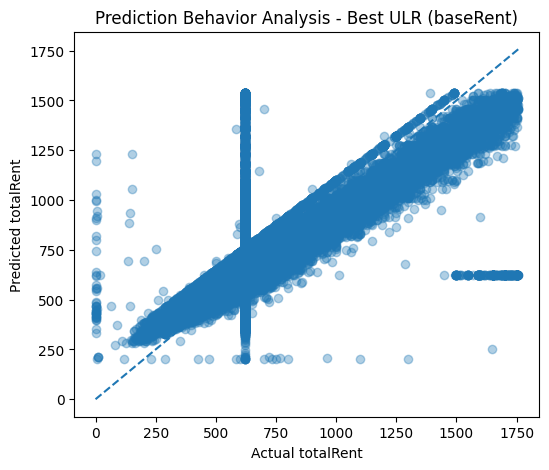

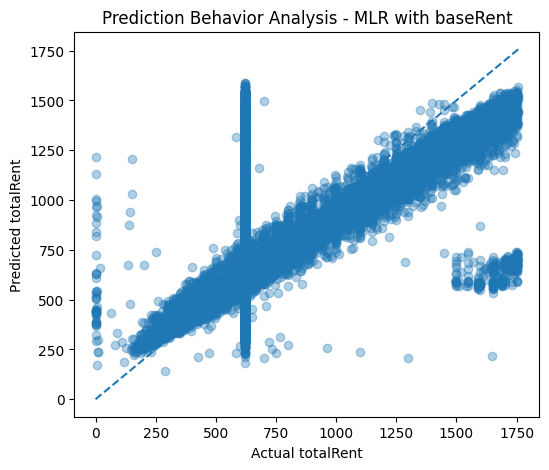

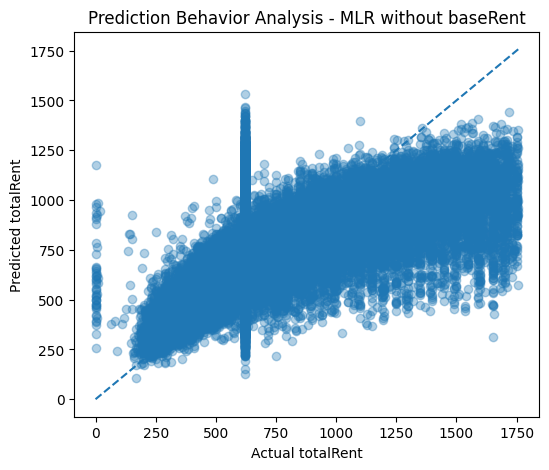

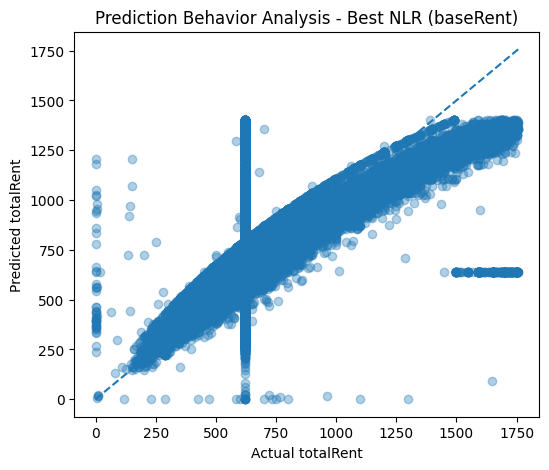

In [16]:
for label, info in selected_models.items():
    y_true_plot = np.asarray(info["test_true"])
    y_pred_plot = np.asarray(info["test_pred"])

    plt.figure(figsize=(6, 5))
    plt.scatter(y_true_plot, y_pred_plot, alpha=0.35)
    plt.plot(
        [y_true_plot.min(), y_true_plot.max()],
        [y_true_plot.min(), y_true_plot.max()],
        linestyle="--"
    )
    plt.xlabel("Actual totalRent")
    plt.ylabel("Predicted totalRent")
    plt.title(f"Prediction Behavior Analysis - {label}")
    plt.show()

## **8.3. Residual Analysis**

Residual analysis is used to examine the error structure of each selected model.

For each model:
- the residuals are computed as `actual - predicted`
- the residuals are plotted against the predicted values

A well-behaved model should produce residuals that are:
- centered around zero
- randomly scattered
- free from obvious patterns or systematic bias

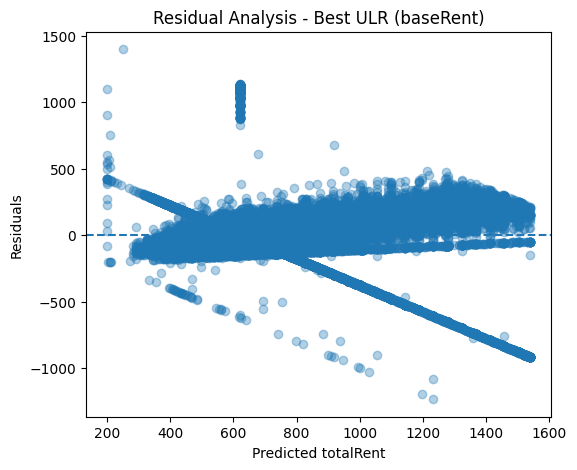

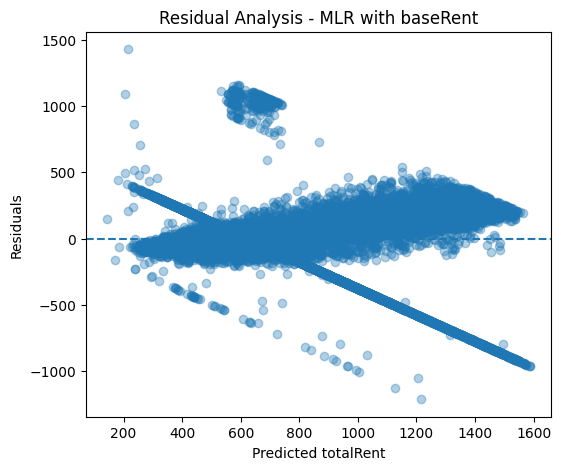

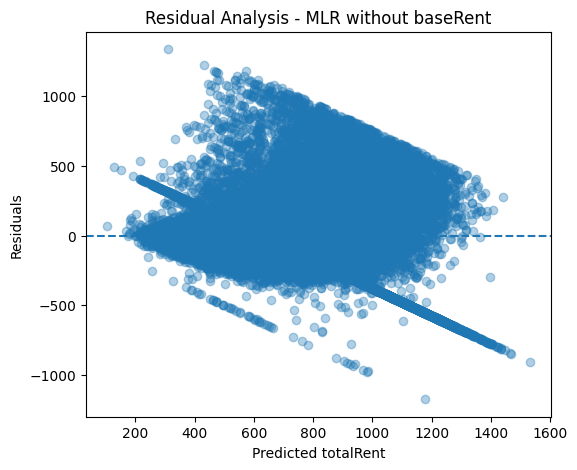

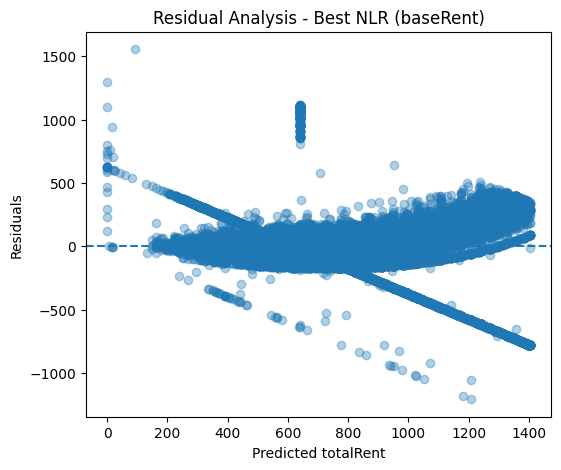

In [17]:
for label, info in selected_models.items():
    y_true_plot = np.asarray(info["test_true"])
    y_pred_plot = np.asarray(info["test_pred"])
    residuals = y_true_plot - y_pred_plot

    plt.figure(figsize=(6, 5))
    plt.scatter(y_pred_plot, residuals, alpha=0.35)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted totalRent")
    plt.ylabel("Residuals")
    plt.title(f"Residual Analysis - {label}")
    plt.show()

## **8.4. Error Distribution Analysis**

This step examines the distribution of prediction errors for each selected model.

The residual distribution helps assess:
- whether the errors are centered near zero
- whether the spread of the errors is narrow or wide
- whether the model tends to produce skewed or extreme prediction errors

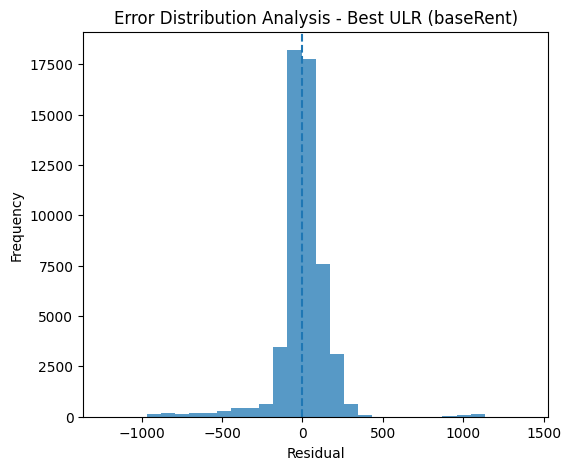

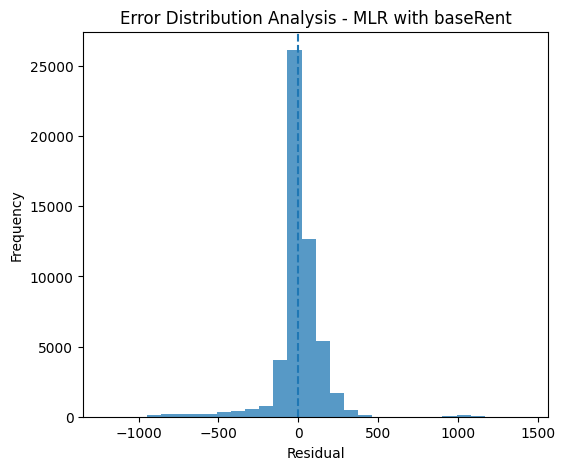

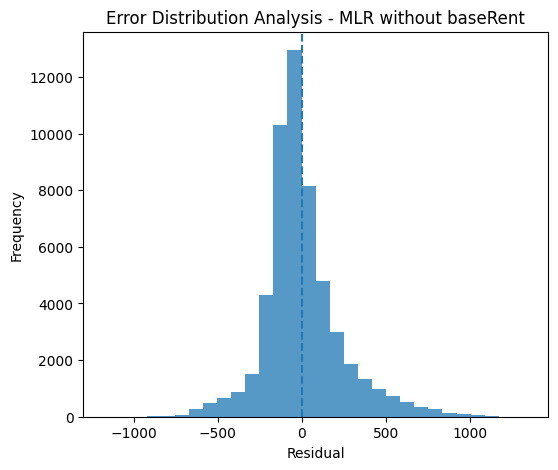

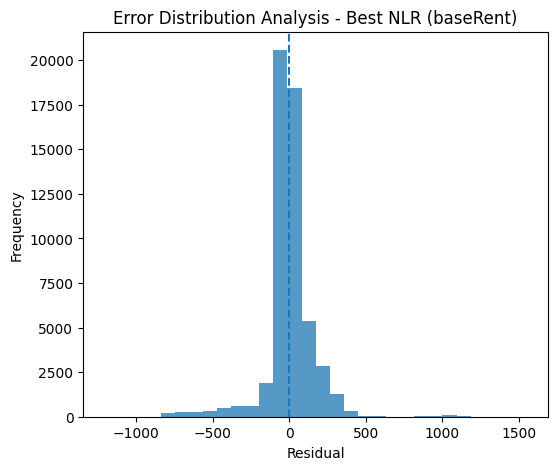

In [18]:
for label, info in selected_models.items():
    y_true_plot = np.asarray(info["test_true"])
    y_pred_plot = np.asarray(info["test_pred"])
    residuals = y_true_plot - y_pred_plot

    plt.figure(figsize=(6, 5))
    plt.hist(residuals, bins=30, alpha=0.75)
    plt.axvline(0, linestyle="--")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title(f"Error Distribution Analysis - {label}")
    plt.show()